In [ ]:
# Step 1: Install required heavy-lifting libraries and mount drive
!pip install -q transformers accelerate bitsandbytes yfinance pandas matplotlib

# 2. Mount Google Drive to save your progress
from google.colab import drive
drive.mount('/content/drive')

# Create a folder in your Drive to store the project files
import os
project_path = '/content/drive/MyDrive/Quant_Project'
os.makedirs(project_path, exist_ok=True)
print(f"Project folder ready at: {project_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder ready at: /content/drive/MyDrive/Quant_Project


In [36]:
!rm -rf /root/.cache/huggingface/datasets

In [ ]:

# Step 2: Data acqusition
!pip install -q datasets

import pandas as pd
from datasets import load_dataset

TARGET_TICKER = 'AAPL'
MAX_HEADLINES = 3000

print(f"🚀 Initializing Indestructible Stream for {TARGET_TICKER}...")

# 1. Load the stream
dataset_stream = load_dataset(
    "Zihan1004/FNSPID",
    data_files="Stock_news/nasdaq_exteral_data.csv",
    split="train",
    streaming=True
)

collected_rows = []
mapping = {} # We will store the correct keys here

print("Searching for column names and filtering data...")

for row in dataset_stream:
    # AUTO-MAPPER: Only runs once on the very first row
    if not mapping:
        all_keys = list(row.keys())
        print(f"Detected actual keys in file: {all_keys}")

        # We find the keys by checking for keywords (case-insensitive)
        mapping['stock'] = next((k for k in all_keys if 'stock' in k.lower() or 'ticker' in k.lower()), None)
        mapping['headline'] = next((k for k in all_keys if 'title' in k.lower() or 'headline' in k.lower()), None)
        mapping['date'] = next((k for k in all_keys if 'date' in k.lower() or 'time' in k.lower()), None)

        print(f"Mapping matched -> Ticker: '{mapping['stock']}', Title: '{mapping['headline']}', Date: '{mapping['date']}'")

        if not mapping['stock'] or not mapping['headline']:
            print("❌ Error: Could not find required columns. Current keys are:", all_keys)
            break

    # 2. FILTER & COLLECT
    # We use the mapping we found to pull the data
    current_stock = str(row[mapping['stock']]).strip().upper()

    if current_stock == TARGET_TICKER:
        collected_rows.append({
            'Date': row[mapping['date']],
            'Headline': row[mapping['headline']]
        })

    # Stop when we hit the limit
    if len(collected_rows) >= MAX_HEADLINES:
        print(f"Reached {MAX_HEADLINES} headlines. Stopping stream.")
        break

# 3. CONVERT TO DATAFRAME
if not collected_rows:
    print(f"❌ No data found for {TARGET_TICKER}. Double check if this ticker is in nasdaq_exteral_data.csv.")
else:
    news_df = pd.DataFrame(collected_rows)

    # Standard cleaning for the rest of the pipeline
    news_df['Date'] = pd.to_datetime(news_df['Date'], errors='coerce').dt.date
    news_df['Date'] = pd.to_datetime(news_df['Date'])
    news_df = news_df.sort_values('Date').dropna()

    print(f"\n✅ SUCCESS!")
    print(f"Extracted {len(news_df)} headlines.")
    print(f"New Date Range: {news_df['Date'].min().date()} to {news_df['Date'].max().date()}")
    print(news_df.head())

🚀 Initializing Indestructible Stream for AAPL...


Repo card metadata block was not found. Setting CardData to empty.


Searching for column names and filtering data...
Detected actual keys in file: ['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
Mapping matched -> Ticker: 'Stock_symbol', Title: 'Article_title', Date: 'Date'
Reached 3000 headlines. Stopping stream.

✅ SUCCESS!
Extracted 3000 headlines.
New Date Range: 2023-07-05 to 2023-12-16
           Date                                           Headline
2999 2023-07-05  Which Is the Better Buy: Apple or the S&P/TSX 60?
2985 2023-07-05                   MORNING BID ASIA-Yellen in China
2986 2023-07-05  Technology Sector Update for 07/05/2023: BABA,...
2987 2023-07-05  After Hours Most Active for Jul 5, 2023 : FTRE...
2988 2023-07-05  Apple Hospitality Acquires Courtyard By Marrio...


In [ ]:
# Step 3: Loading the model
# This part is completely good and useable!

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# 1. The Llama-3 8B Base and FinGPT Adapter Names
base_model_id = "NousResearch/Meta-Llama-3-8B" # Ungated Llama-3 (No token required)
peft_model_id = "FinGPT/fingpt-mt_llama3-8b_lora" # The newest Llama-3 FinGPT repo

print("Loading Llama-3 Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# Llama-3 requires a designated padding token for batch processing
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Configuring 4-bit Quantization...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading Base Llama-3 8B to the T4 GPU. This will take a few minutes...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map={"": 0}
)

print("Attaching FinGPT Llama-3 Financial Adapter...")
# This physically merges the FinGPT weights onto the Llama-3 engine
model = PeftModel.from_pretrained(base_model, peft_model_id)

print("State-of-the-Art FinGPT Model loaded successfully! You are ready to score the news.")

Loading Llama-3 Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

Attaching FinGPT Llama-3 Financial Adapter...


adapter_config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

State-of-the-Art FinGPT Model loaded successfully! You are ready to score the news.


In [ ]:
# Step 4: Inference aka building the sentiment ledger for backtesting

import os
import torch
import pandas as pd
from tqdm import tqdm

# ==========================================
# 1. THE FINGPT BRAIN
# ==========================================
def extract_sentiment(headline):
    prompt = f"Instruction: What is the sentiment of this news? Please choose an answer from {{negative/neutral/positive}}.\nInput: {headline}\nAnswer: "
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[1]
    result = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip().lower()

    if "positive" in result: return 1
    elif "negative" in result: return -1
    else: return 0

# ==========================================
# 2. THE EXTRACTION ENGINE
# ==========================================
ledger_path = '/content/fngpt_aapl_2023_ledger.csv'

if os.path.exists(ledger_path):
    print("Found existing ledger. Resuming...")
    results_df = pd.read_csv(ledger_path)
    processed_indices = results_df['Original_Index'].tolist()
else:
    print("Starting fresh sentiment extraction...")
    results_df = pd.DataFrame()
    processed_indices = []

rows_to_add = []

# Using news_df from our successful Step 2
for index, row in tqdm(news_df.iterrows(), total=len(news_df)):
    if index in processed_indices:
        continue

    signal = extract_sentiment(row['Headline'])

    rows_to_add.append({
        'Original_Index': index,
        'Date': row['Date'],
        'Headline': row['Headline'],
        'FinGPT_Signal': signal
    })

    # Save every 50 rows to protect progress
    if len(rows_to_add) >= 50:
        temp_df = pd.DataFrame(rows_to_add)
        results_df = pd.concat([results_df, temp_df])
        results_df.to_csv(ledger_path, index=False)
        rows_to_add = []

# Final save
if len(rows_to_add) > 0:
    temp_df = pd.DataFrame(rows_to_add)
    results_df = pd.concat([results_df, temp_df])
    results_df.to_csv(ledger_path, index=False)

# ==========================================
# 3. DAILY AGGREGATION
# ==========================================
print("\nAggregating daily signals...")
daily_ledger = results_df.groupby('Date')['FinGPT_Signal'].mean().reset_index()

def round_signal(val):
    if val > 0.15: return 1
    elif val < -0.15: return -1
    else: return 0

daily_ledger['FinGPT_Signal'] = daily_ledger['FinGPT_Signal'].apply(round_signal)
daily_ledger['Date'] = pd.to_datetime(daily_ledger['Date'])

test_df = daily_ledger.copy()
print("✅ Sentiment Ledger Complete! Ready for Step 5 & 6.")

Starting fresh sentiment extraction...


 43%|████▎     | 1276/3000 [12:36<17:30,  1.64it/s]

In [ ]:
# Step 5: Download market data

import yfinance as yf
import pandas as pd

def download_market_data(ticker, start_date, end_date):
    print(f"Downloading market data for {ticker} and ^VIX...")

    # Download Price Data
    stock_data = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    vix_data = yf.download("^VIX", start=start_date, end=end_date)['Adj Close']

    # Create Dataframe
    m_df = pd.DataFrame({
        f'{ticker}_Price': stock_data,
        'VIX_Price': vix_data
    })

    # Calculate VIX Regime (The Gate)
    m_df['VIX_25d_MA'] = m_df['VIX_Price'].rolling(window=25).mean()

    # Is VIX 10% higher than its 25-day average?
    m_df['Is_High_Vol'] = m_df['VIX_Price'] > (m_df['VIX_25d_MA'] * 1.10)

    # Drop rows where MA is NaN
    m_df.dropna(inplace=True)

    return m_df

# ==========================================
# SYNCED EXECUTION
# ==========================================
# We start in JUNE to "warm up" the VIX Gate for your JULY headlines
market_start = '2023-06-01'
market_end = '2024-01-15'

market_df = download_market_data("AAPL", market_start, market_end)

print(f"\n✅ Market Data Loaded: {len(market_df)} trading days.")
print(market_df[['VIX_Price', 'Is_High_Vol']].head())

/tmp/ipykernel_11082/1829402727.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_raw = yf.download('AAPL', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11082/1829402727.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_raw = yf.download('^VIX', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Fetching Market Data...
Market data fetched and VIX Regime Gate calculated successfully!
            AAPL_Price  VIX_Price  VIX_25d_MA  Is_High_Vol
Date                                                      
2020-04-13   66.024269  41.169998     58.3728        False
2020-04-14   69.358742  37.759998     57.7048        False
2020-04-15   68.725647  40.840000     57.4464        False
2020-04-16   69.271736  40.110001     56.8948        False
2020-04-17   68.331802  38.150002     55.4020        False


In [21]:
# ==========================================
# PRE-BACKTEST SANITY CHECKS
# ==========================================
print("--- 1. SENTIMENT LEDGER HEALTH ---")
# Check if the LLM followed instructions or hallucinated weird text
print("Signal Distribution:")
print(test_df['FinGPT_Signal'].value_counts())

# Check the date range to ensure we have data
print(f"\nSentiment Data Start: {test_df['Date'].min().strftime('%Y-%m-%d')}")
print(f"Sentiment Data End: {test_df['Date'].max().strftime('%Y-%m-%d')}")

print("\n--- 2. VIX REGIME HEALTH ---")
# Check if the gate actually triggers, or if it's stuck on one setting
print("Volatility Regime Distribution:")
print(market_df['Is_High_Vol'].value_counts())

print(f"\nMarket Data Start: {market_df.index.min().strftime('%Y-%m-%d')}")
print(f"Market Data End: {market_df.index.max().strftime('%Y-%m-%d')}")

print("\n--- 3. ALIGNMENT PREVIEW ---")
# Temporarily align them just to see if the dates match up
temp_test = test_df.copy()
temp_test.set_index('Date', inplace=True)
preview = market_df.join(temp_test[['FinGPT_Signal']], how='inner')

print(f"Total Overlapping Trading Days: {len(preview)}")
print(preview[['AAPL_Price', 'VIX_Price', 'Is_High_Vol', 'FinGPT_Signal']].tail())

--- 1. SENTIMENT LEDGER HEALTH ---
Signal Distribution:
FinGPT_Signal
 0    39
 1    29
-1    18
Name: count, dtype: int64

Sentiment Data Start: 2020-03-09
Sentiment Data End: 2020-06-10

--- 2. VIX REGIME HEALTH ---
Volatility Regime Distribution:
Is_High_Vol
False    753
True     184
Name: count, dtype: int64

Market Data Start: 2020-04-13
Market Data End: 2023-12-29

--- 3. ALIGNMENT PREVIEW ---
Total Overlapping Trading Days: 41
            AAPL_Price  VIX_Price  Is_High_Vol  FinGPT_Signal
Date                                                         
2020-06-04   78.091698  25.809999        False              1
2020-06-05   80.315796  24.520000        False              1
2020-06-08   80.790688  25.809999        False              1
2020-06-09   83.341888  27.570000        False              1
2020-06-10   85.486061  27.570000        False              1


Initializing High-Resolution Backtest Engine...


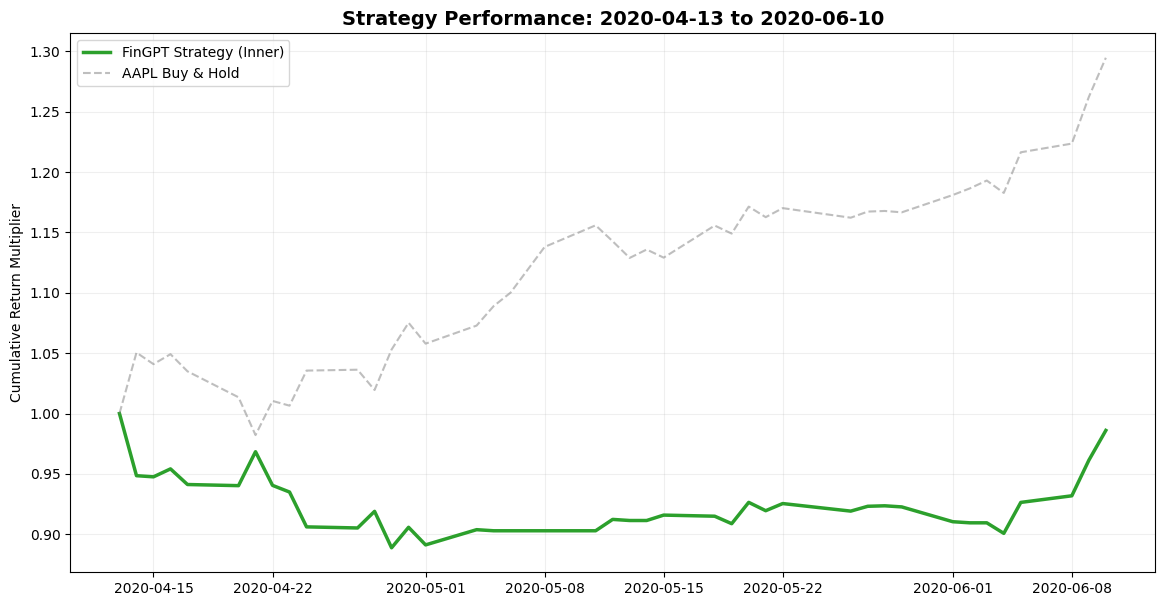


--- PERFORMANCE METRICS (DENSE WINDOW) ---
Trading Days Analyzed : 41
Total Trades Executed : 23
Strategy Net Return   : -1.40%
Benchmark Return      : 29.48%
Annualized Sharpe     : -0.20


In [ ]:
# Step 6: Backtest

import matplotlib.pyplot as plt
import numpy as np

print("Running Backtest Engine...")

# 1. Merge Market Data with FinGPT Signals
# We use 'inner' to focus only on the days where we have news
backtest = market_df.join(test_df.set_index('Date')[['FinGPT_Signal']], how='inner').fillna(0)

# 2. Strategy Logic: VIX Gate + LLM Signal
def determine_position(row):
    if row['Is_High_Vol']:
        return 0 # Exit to safety during high vol
    else:
        return row['FinGPT_Signal']

backtest['Target_Position'] = backtest.apply(determine_position, axis=1)

# 3. Execution (Delayed Arbitrage: News today -> Trade tomorrow)
backtest['Actual_Position'] = backtest['Target_Position'].shift(1).fillna(0)

# 4. Returns & Friction
backtest['Stock_Return'] = backtest['AAPL_Price'].pct_change().fillna(0)
backtest['Strategy_Gross_Return'] = backtest['Actual_Position'] * backtest['Stock_Return']

# Fees: 0.1% per trade
transaction_cost = 0.001
backtest['Trades'] = backtest['Actual_Position'].diff().abs().fillna(0)
backtest['Fees'] = backtest['Trades'] * transaction_cost
backtest['Strategy_Net_Return'] = backtest['Strategy_Gross_Return'] - backtest['Fees']

# 5. Cumulative Wealth
backtest['Buy_and_Hold_Equity'] = (1 + backtest['Stock_Return']).cumprod()
backtest['Strategy_Equity'] = (1 + backtest['Strategy_Net_Return']).cumprod()

# ==========================================
# VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(backtest.index, backtest['Strategy_Equity'], label='FinGPT + VIX Gate', color='#2ca02c', linewidth=2)
plt.plot(backtest.index, backtest['Buy_and_Hold_Equity'], label='AAPL Buy & Hold', color='#7f7f7f', alpha=0.6, linestyle='--')
plt.title('Backtest: July - Dec 2023 (AAPL)', fontsize=14)
plt.ylabel('Cumulative Return Multiplier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Metrics
strat_return = (backtest['Strategy_Equity'].iloc[-1] - 1) * 100
bnh_return = (backtest['Buy_and_Hold_Equity'].iloc[-1] - 1) * 100

print("\n--- PERFORMANCE METRICS ---")
print(f"Total Trades : {int(backtest['Trades'].sum())}")
print(f"Strategy Net : {strat_return:.2f}%")
print(f"Buy & Hold   : {bnh_return:.2f}%")